<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [22]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

In [23]:
# 1. Normalizar datos y preparar variables

# Identificar columnas numéricas y categóricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Columnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

# Dataset numérico: imputar nulos con el promedio de cada columna
df_numerico = df[columnas_numericas].copy()
df_numerico = df_numerico.fillna(df_numerico.mean())

# Normalizar variables numéricas con MinMaxScaler
scaler = MinMaxScaler()
df_numerico_scaled = pd.DataFrame(
    scaler.fit_transform(df_numerico),
    columns=columnas_numericas,
    index=df.index
)

# Dataset categórico: imputar nulos con "Desconocido" y aplicar get_dummies
df_categorico = df[columnas_categoricas].copy()
df_categorico = df_categorico.fillna("Desconocido")

df_categorico_dummies = pd.get_dummies(
    df_categorico,
    drop_first=False,
    dtype=int
)

# Juntar ambos datasets en uno procesado
df_procesado = pd.concat(
    [df_numerico_scaled, df_categorico_dummies],
    axis=1
)

print("\nDimensiones del dataset original:")
print(df.shape)

print("\nDimensiones del dataset procesado:")
print(df_procesado.shape)

print("\nValores nulos en df_procesado:")
print(df_procesado.isnull().sum().sum())

df_procesado.head()

Columnas numéricas:
['year', 'desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']

Columnas categóricas:
['clase_tipo', 'traccion_tipo', 'transmision_tipo', 'combustible_tipo', 'tamano_motor_tipo', 'consumo_tipo', 'co2_tipo']

Dimensiones del dataset original:
(36791, 12)

Dimensiones del dataset procesado:
(36791, 37)

Valores nulos en df_procesado:
0


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
1,0.000000,0.461538,0.285714,0.527672,0.475113,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0.029412,0.243590,0.142857,0.424351,0.360294,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3,0.029412,0.461538,0.285714,0.527672,0.475113,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,0.088235,0.410256,0.285714,0.424351,0.360294,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0


En esta etapa se preparó la base de vehículos para poder aplicar modelos de clustering. El dataset original contiene **36.791 observaciones** y **12 columnas**. De estas variables, 5 son numéricas: `year`, `desplazamiento`, `cilindros`, `co2` y `consumo_litros_milla`; mientras que 7 son categóricas: `clase_tipo`, `traccion_tipo`, `transmision_tipo`, `combustible_tipo`, `tamano_motor_tipo`, `consumo_tipo` y `co2_tipo`.

Las variables numéricas fueron normalizadas mediante `MinMaxScaler`, dejando sus valores en una escala común entre 0 y 1. Esto es importante porque KMeans utiliza distancias para formar los grupos, por lo que variables con escalas mayores podrían dominar artificialmente el resultado.

Las variables categóricas fueron transformadas mediante `get_dummies()`, convirtiéndose en variables binarias. Como resultado, el dataset procesado aumentó de **12 a 37 columnas**. Además, no quedaron valores nulos en la base procesada, lo que indica que los datos quedaron listos para aplicar clustering.

### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

Cantidad de observaciones por cluster:


,count
cluster,
0,6057
1,7127
2,4811
3,3589
4,3987
5,3843
6,4690
7,2687



Centroides del modelo KMeans:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.407520,0.331445,0.256838,0.354296,0.282160,0.181308,0.084049,0.090654,0.133421,0.184610,...,-7.244205e-15,1.370542e-02,9.810106e-01,1.651255e-04,5.118890e-03,1.155878e-03,-1.709743e-14,0.998844,-6.022960e-15,-1.582068e-15
1,0.412095,0.576135,0.420153,0.506906,0.449646,0.333801,0.003788,0.035639,0.038586,0.138628,...,4.026940e-02,-1.662559e-14,9.120247e-03,9.506104e-01,-6.716849e-15,9.821804e-04,-3.147482e-14,0.000140,9.988775e-01,1.196265e-14
2,0.577350,0.270715,0.210649,0.305306,0.226827,0.026185,0.093724,0.073150,0.192228,0.400042,...,6.234414e-04,9.709061e-01,8.312552e-04,1.518230e-14,2.763924e-02,3.302913e-15,9.679967e-01,0.029925,-1.565414e-14,2.078138e-03
3,0.438505,0.159462,0.141141,0.242197,0.156456,0.016439,0.124826,0.006408,0.093062,0.709668,...,6.716849e-15,-1.204592e-14,1.704192e-14,1.251776e-14,1.000000e+00,9.603429e-15,8.358874e-04,0.001393,-7.077672e-15,9.977710e-01
4,0.588730,0.362290,0.299545,0.354136,0.282247,0.001505,0.083020,0.086531,0.189616,0.558816,...,5.016303e-04,2.608478e-02,9.731628e-01,1.360023e-14,2.508151e-04,2.357662e-02,7.771561e-16,0.976423,-1.040834e-14,-1.634803e-14



Promedio de variables numéricas por cluster:


...

,year,desplazamiento,cilindros,co2,consumo_litros_milla
cluster,,,,,
0,1984,3.0,6.0,493.722,0.210
1,1984,5.0,8.0,592.467,0.252
2,2017,2.0,4.0,423.190,0.180
3,1985,2.0,4.0,370.292,0.158
4,2005,3.0,6.0,493.722,0.199
5,2017,2.0,4.0,370.292,0.158
6,1985,4.3,6.0,555.438,0.223
7,1984,2.0,4.0,423.190,0.180



Moda de variables categóricas por cluster:


,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo
cluster,,,,,,,
0,Coches pequeños,dos,Automatica,Normal,mediano,moderado,moderado
1,Camionetas,dos,Automatica,Normal,muy grande,muy alto,muy alto
2,Coches pequeños,dos,Automatica,Normal,pequeño,bajo,bajo
3,Coches pequeños,dos,Manual,Normal,muy pequeño,muy bajo,muy bajo
4,Coches pequeños,dos,Automatica,Premium,mediano,moderado,moderado
5,Coches pequeños,dos,Automatica,Normal,muy pequeño,muy bajo,muy bajo
6,Camionetas,dos,Automatica,Normal,grande,alto,alto
7,Coches pequeños,dos,Manual,Normal,pequeño,bajo,bajo



Resumen general de clusters:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo
cluster,,,,,,,,,,,,
0,1997.858,3.185,5.596,468.523,0.199,Coches pequeños,dos,Automatica,Normal,mediano,moderado,moderado
1,1998.011,5.094,7.882,657.853,0.279,Camionetas,dos,Automatica,Normal,muy grande,muy alto,muy alto
2,2003.628,2.712,4.949,407.751,0.173,Coches pequeños,dos,Automatica,Normal,pequeño,bajo,bajo
3,1998.909,1.843,3.975,329.463,0.140,Coches pequeños,dos,Manual,Normal,muy pequeño,muy bajo,muy bajo
4,2004.017,3.426,6.194,468.331,0.199,Coches pequeños,dos,Automatica,Premium,mediano,moderado,moderado
5,2007.623,1.998,4.109,326.782,0.140,Coches pequeños,dos,Automatica,Normal,muy pequeño,muy bajo,muy bajo
6,2000.268,4.118,6.584,537.752,0.229,Camionetas,dos,Automatica,Normal,grande,alto,alto
7,1998.517,2.345,4.431,406.901,0.173,Coches pequeños,dos,Manual,Normal,pequeño,bajo,bajo


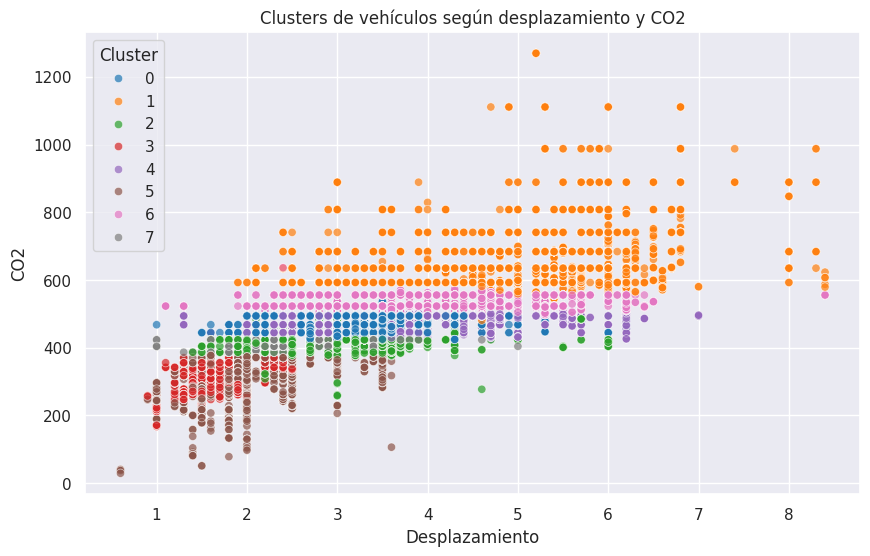

In [24]:
# 2. Realizar ajuste mediante KMeans con 8 clusters

# Ajustar modelo KMeans
kmeans_8 = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

clusters = kmeans_8.fit_predict(df_procesado)

# Asociar cada vehículo a su cluster
df_cluster = df.copy()
df_cluster["cluster"] = clusters

df_procesado_cluster = df_procesado.copy()
df_procesado_cluster["cluster"] = clusters

print("Cantidad de observaciones por cluster:")
display(df_cluster["cluster"].value_counts().sort_index())

# Centroides en el espacio procesado
centroides = pd.DataFrame(
    kmeans_8.cluster_centers_,
    columns=df_procesado.columns
)

print("\nCentroides del modelo KMeans:")
display(centroides.head())

# Resumen de variables numéricas por cluster: promedio
resumen_numerico_promedio = (
    df_cluster
    .groupby("cluster")[columnas_numericas]
    .mean()
    .round(3)
)

print("\nPromedio de variables numéricas por cluster:")
display(resumen_numerico_promedio)

# Resumen de variables numéricas por cluster: moda
resumen_numerico_moda = (
    df_cluster
    .groupby("cluster")[columnas_numericas]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .round(3)
)

print("\nModa de variables numéricas por cluster:")
display(resumen_numerico_moda)

# Resumen de variables categóricas por cluster: moda
resumen_categorico_moda = (
    df_cluster
    .groupby("cluster")[columnas_categoricas]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

print("\nModa de variables categóricas por cluster:")
display(resumen_categorico_moda)

# Tabla final resumida combinando principales variables
resumen_cluster = resumen_numerico_promedio.join(
    resumen_categorico_moda,
    how="left"
)

print("\nResumen general de clusters:")
display(resumen_cluster)

# Visualización simple de los clusters según emisiones y desplazamiento
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x="desplazamiento",
    y="co2",
    hue="cluster",
    palette="tab10",
    alpha=0.7
)
plt.title("Clusters de vehículos según desplazamiento y CO2")
plt.xlabel("Desplazamiento")
plt.ylabel("CO2")
plt.legend(title="Cluster")
plt.show()

Al aplicar KMeans con **8 clusters**, los vehículos fueron agrupados según características como año, desplazamiento, cilindros, emisiones de CO2, consumo, clase de vehículo, tipo de transmisión, combustible y tamaño de motor.

La distribución de observaciones por cluster fue relativamente diversa. El cluster más grande fue el **cluster 1**, con **7.127 vehículos**, seguido por el **cluster 0**, con **6.057**, y el **cluster 2**, con **4.811**. El cluster más pequeño fue el **cluster 7**, con **2.687 vehículos**. Esto indica que los grupos no quedaron perfectamente balanceados, pero sí permiten separar distintos perfiles de vehículos.

Los resultados muestran diferencias claras entre clusters. El **cluster 1** agrupa principalmente camionetas automáticas, con motores muy grandes, alto desplazamiento promedio (**5,094**), mayor número de cilindros (**7,882**), mayores emisiones de CO2 (**657,853**) y mayor consumo de combustible. Por lo tanto, representa el grupo de vehículos más contaminantes y de mayor consumo.

En contraste, los **clusters 3 y 5** presentan los valores más bajos de emisiones y consumo. El cluster 3 tiene un desplazamiento promedio de **1,843**, cerca de **3,975 cilindros**, CO2 promedio de **329,463** y consumo promedio de **0,140** litros por milla. El cluster 5 muestra un comportamiento muy similar, con desplazamiento promedio de **1,998**, CO2 de **326,782** y consumo de **0,140**. Estos grupos representan vehículos más pequeños, eficientes y de menor impacto ambiental.

El **cluster 6** también destaca como un grupo de vehículos de mayor tamaño, principalmente camionetas automáticas con motor grande, consumo alto y CO2 alto. Su CO2 promedio es **537,752**, menor que el cluster 1, pero igualmente elevado.

En síntesis, KMeans logró diferenciar perfiles de vehículos: grupos de alto consumo y altas emisiones, como los clusters 1 y 6; grupos intermedios, como los clusters 0, 2, 4 y 7; y grupos más eficientes y menos contaminantes, como los clusters 3 y 5.

### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

Resultados de la regla del codo:


,n_clusters,inercia
0,5,102312.085447
1,10,83144.232279
2,20,66112.951080
3,30,56470.203100
4,50,44806.524076
5,75,36571.910332
6,100,31085.998994
7,200,17754.646031
8,300,11254.821217


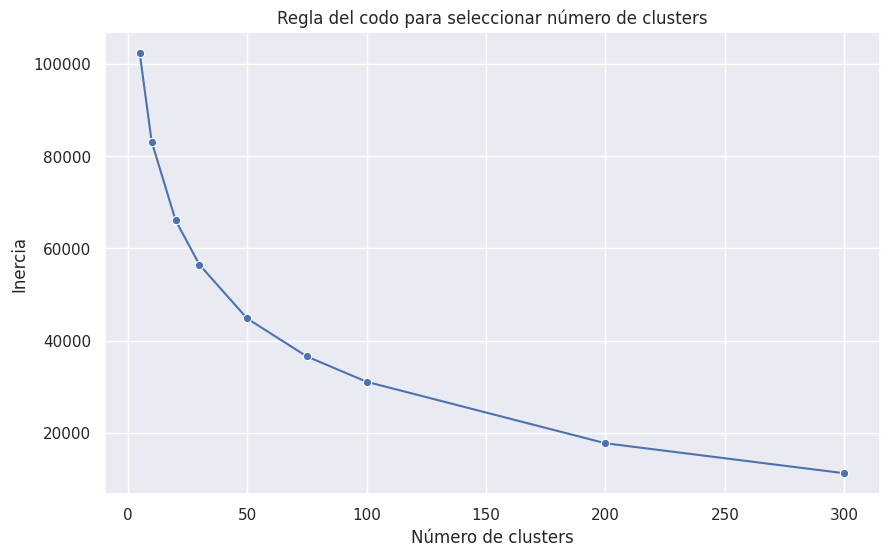


Reducción porcentual de la inercia al aumentar k:


,n_clusters,inercia,reduccion_inercia_pct
0,5,102312.085447,NaN
1,10,83144.232279,18.734691
2,20,66112.951080,20.484020
3,30,56470.203100,14.585263
4,50,44806.524076,20.654572
5,75,36571.910332,18.378158
6,100,31085.998994,15.000341
7,200,17754.646031,42.885393
8,300,11254.821217,36.609149


In [18]:
# 3. Elegir número de clusters usando regla del codo

lista_clusters = [5, 10, 20, 30, 50, 75, 100, 200, 300]
inercias = []

for k in lista_clusters:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    modelo.fit(df_procesado)
    inercias.append(modelo.inertia_)

df_codo = pd.DataFrame({
    "n_clusters": lista_clusters,
    "inercia": inercias
})

print("Resultados de la regla del codo:")
display(df_codo)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_codo,
    x="n_clusters",
    y="inercia",
    marker="o"
)
plt.title("Regla del codo para seleccionar número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

# Variación porcentual de la inercia entre valores de k
df_codo["reduccion_inercia_pct"] = df_codo["inercia"].pct_change() * -100

print("\nReducción porcentual de la inercia al aumentar k:")
display(df_codo)

La regla del codo se utilizó para evaluar cómo cambia la inercia al aumentar el número de clusters. La inercia disminuye de forma continua a medida que aumenta `k`, pasando de **102.312,09** con 5 clusters a **11.254,82** con 300 clusters. Esto es esperable, ya que al aumentar el número de clusters, las observaciones quedan más cerca de sus centroides.

Sin embargo, el objetivo no es elegir el mayor número de clusters, sino encontrar un punto donde la reducción de la inercia comience a ser menos significativa. En este caso, la reducción no muestra un codo completamente claro, ya que sigue bajando de manera importante incluso para valores altos de `k`.

Entre 5 y 100 clusters, la reducción porcentual de la inercia se mantiene entre aproximadamente **14,6% y 20,7%**. Luego, al pasar de 100 a 200 clusters, la reducción aumenta a **42,9%**, y de 200 a 300 clusters aún baja **36,6%**. Esto sugiere que la estructura de los datos es compleja y que existen muchos subgrupos posibles dentro del mercado de vehículos.

Aun así, para fines interpretativos, usar 8 clusters es razonable porque permite obtener grupos comprensibles sin fragmentar demasiado la base. Si el objetivo fuera maximizar la precisión de segmentación, podría evaluarse un número mayor de clusters, pero eso haría más difícil interpretar cada grupo.

Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [25]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [26]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



Varianza explicada por componente:


,componente,varianza_explicada,varianza_acumulada
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


Componentes necesarios para explicar al menos 90% de la varianza: 8
Componentes necesarios para explicar al menos 95% de la varianza: 10


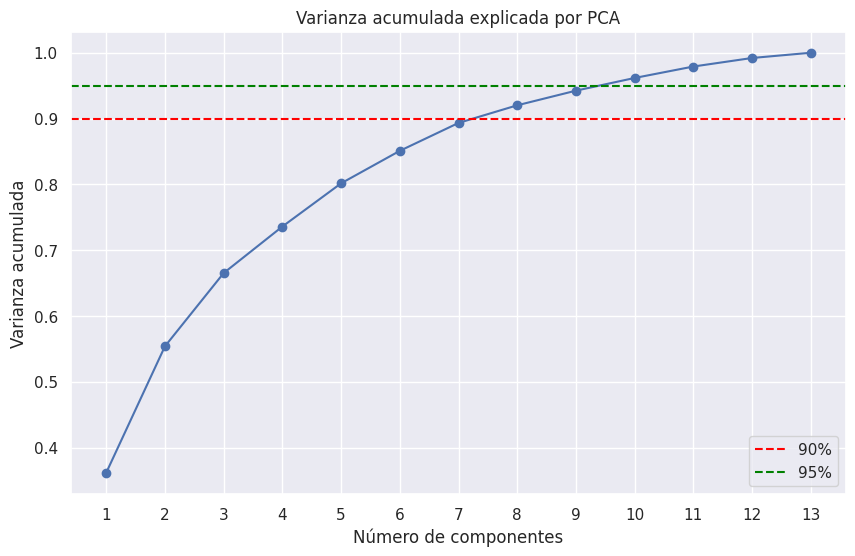


Proyección de observaciones en las dos primeras componentes:


,PC1,PC2,wine_class
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


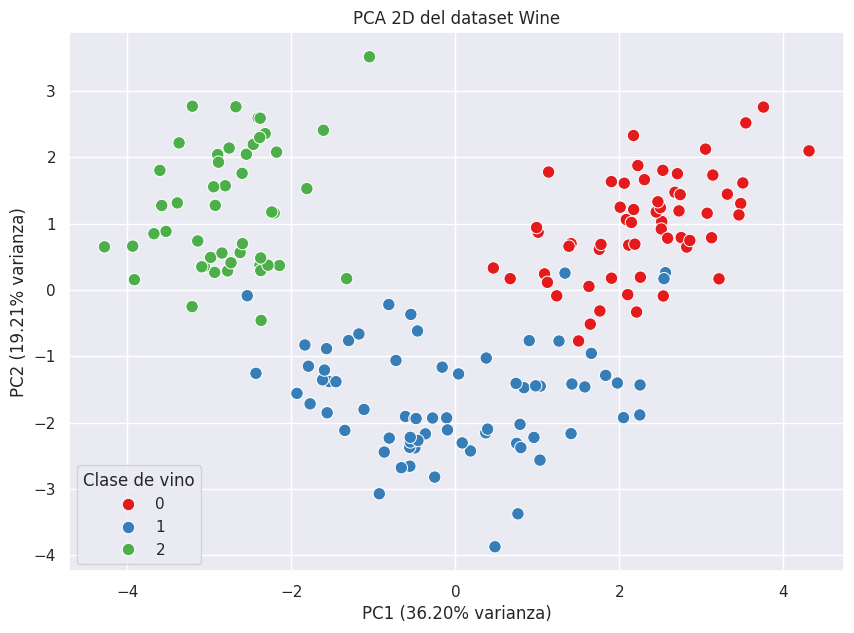

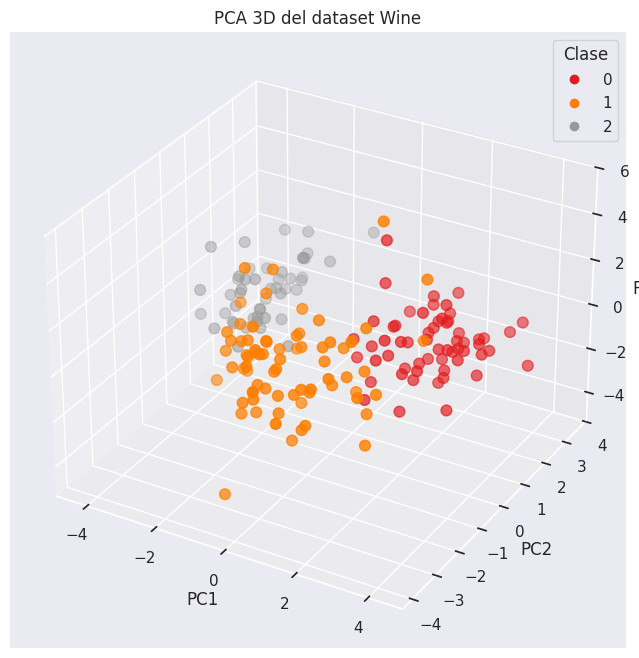


Loadings de las dos primeras componentes principales:


,PC1,PC2
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
nonflavanoid_phenols,-0.298533,0.028779
hue,0.296715,-0.279235
proline,0.286752,0.364903
malic_acid,-0.245188,0.224931
alcalinity_of_ash,-0.239320,-0.010591
alcohol,0.144329,0.483652


<Figure size 1000x600 with 0 Axes>

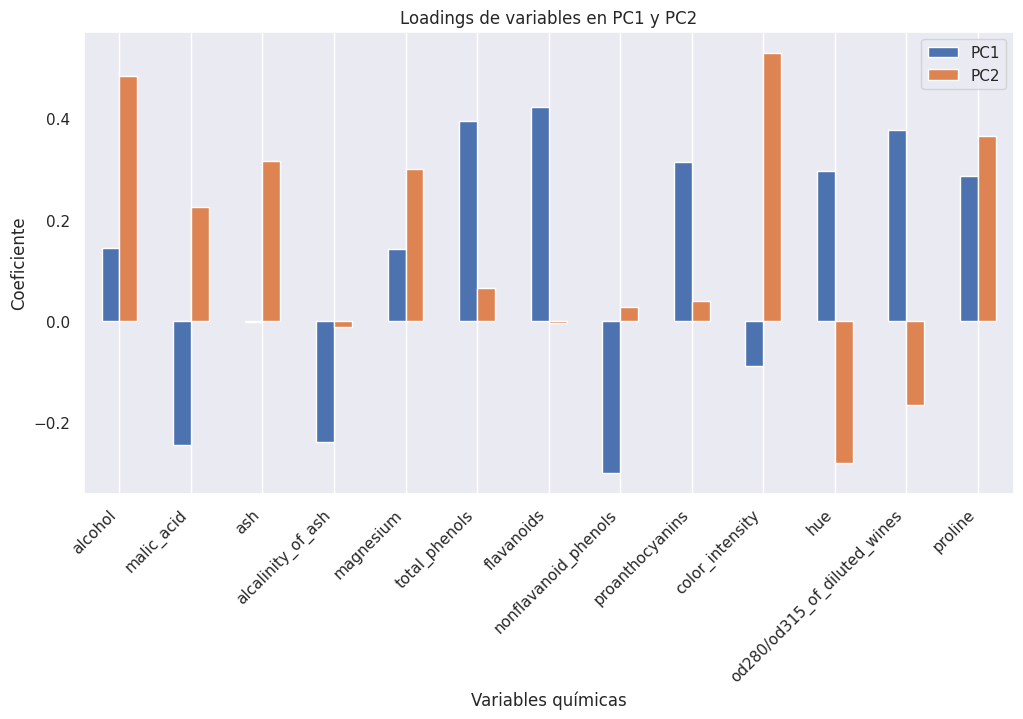

In [19]:
# 1. Análisis detallado con PCA

from sklearn.preprocessing import StandardScaler

# Separar variables y etiqueta
X_wine = wine[features].copy()
y_wine = wine[target].copy()

# Estandarizar variables antes de PCA
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# PCA con todos los componentes
pca = PCA()
X_pca_all = pca.fit_transform(X_wine_scaled)

# Varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

df_varianza = pd.DataFrame({
    "componente": np.arange(1, len(varianza_explicada) + 1),
    "varianza_explicada": varianza_explicada,
    "varianza_acumulada": varianza_acumulada
})

print("Varianza explicada por componente:")
display(df_varianza)

# Componentes necesarios para 90% y 95%
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print(f"Componentes necesarios para explicar al menos 90% de la varianza: {n_90}")
print(f"Componentes necesarios para explicar al menos 95% de la varianza: {n_95}")

# Gráfico de varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(df_varianza["componente"], df_varianza["varianza_acumulada"], marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.axhline(0.95, color="green", linestyle="--", label="95%")
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.xticks(df_varianza["componente"])
plt.legend()
plt.grid(True)
plt.show()

# PCA a 2 componentes para visualización
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_wine_scaled)

df_pca_2 = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"]
)
df_pca_2[target] = y_wine.values

print("\nProyección de observaciones en las dos primeras componentes:")
display(df_pca_2.head())

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca_2,
    x="PC1",
    y="PC2",
    hue=target,
    palette="Set1",
    s=80
)
plt.title("PCA 2D del dataset Wine")
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.2f}% varianza)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.2f}% varianza)")
plt.legend(title="Clase de vino")
plt.show()

# PCA a 3 componentes para visualización
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_wine_scaled)

df_pca_3 = pd.DataFrame(
    X_pca_3,
    columns=["PC1", "PC2", "PC3"]
)
df_pca_3[target] = y_wine.values

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_pca_3["PC1"],
    df_pca_3["PC2"],
    df_pca_3["PC3"],
    c=df_pca_3[target],
    cmap="Set1",
    s=60
)

ax.set_title("PCA 3D del dataset Wine")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Clase")
plt.show()

# Loadings: importancia de variables en PC1 y PC2
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

print("\nLoadings de las dos primeras componentes principales:")
display(loadings.sort_values("PC1", key=abs, ascending=False))

plt.figure(figsize=(10, 6))
loadings[["PC1", "PC2"]].plot(kind="bar", figsize=(12, 6))
plt.title("Loadings de variables en PC1 y PC2")
plt.xlabel("Variables químicas")
plt.ylabel("Coeficiente")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

El análisis PCA se aplicó al dataset Wine con el objetivo de reducir la dimensionalidad de las variables químicas del vino y observar qué proporción de la información total puede representarse en menos componentes.

Los resultados muestran que la primera componente principal explica aproximadamente **36,20%** de la varianza total, mientras que la segunda componente explica **19,21%**. En conjunto, las dos primeras componentes explican cerca de **55,41%** de la variabilidad de los datos. Esto permite visualizar parcialmente la estructura del dataset en dos dimensiones, aunque todavía queda una parte importante de información distribuida en componentes posteriores.

Para explicar al menos **90%** de la varianza se necesitan **8 componentes**, mientras que para explicar al menos **95%** se requieren **10 componentes**. Esto indica que aunque el PCA permite reducir dimensionalidad, no basta con solo dos componentes si el objetivo es conservar casi toda la información original.

En la visualización 2D con PCA se observa una separación razonable entre las clases de vino. Los centros promedio por clase muestran que la clase 0 se ubica principalmente hacia valores positivos de PC1 y PC2, la clase 1 se ubica cerca del centro pero con PC2 negativo, y la clase 2 se diferencia con valores negativos de PC1 y positivos de PC2. Esto confirma que PCA logra capturar patrones relevantes para distinguir las clases.

Los loadings indican que las variables más importantes en la primera componente son `flavanoids`, `total_phenols`, `od280/od315_of_diluted_wines`, `proanthocyanins` y `nonflavanoid_phenols`. Esto sugiere que PC1 está muy asociada a características químicas relacionadas con fenoles y flavonoides. En cambio, PC2 está más influida por variables como `color_intensity`, `alcohol`, `proline`, `ash` y `magnesium`, por lo que captura otra dimensión química del vino.



### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.



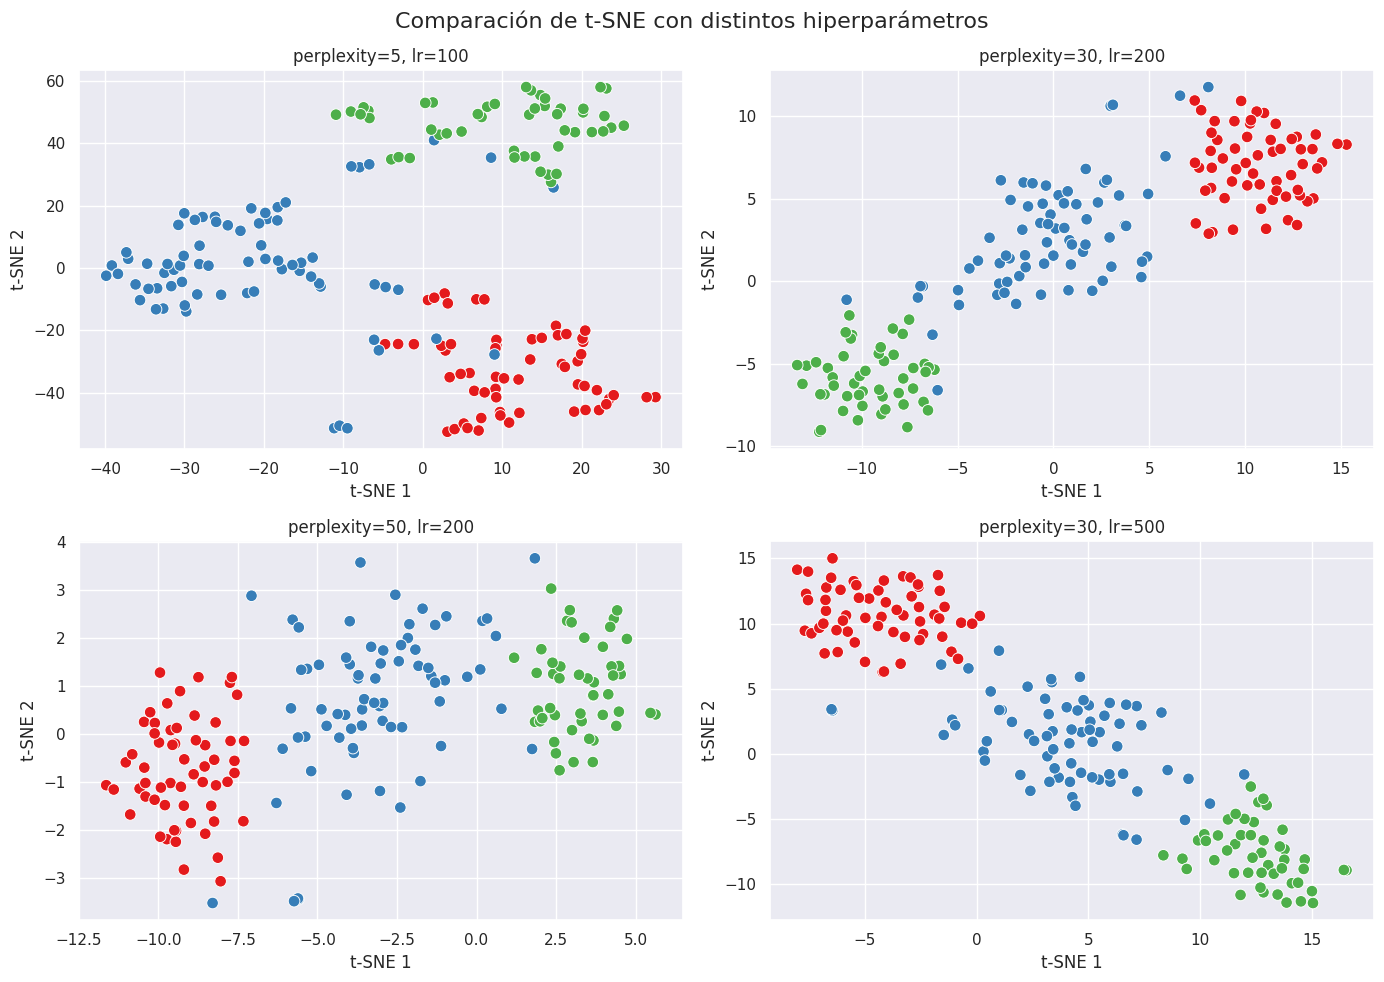

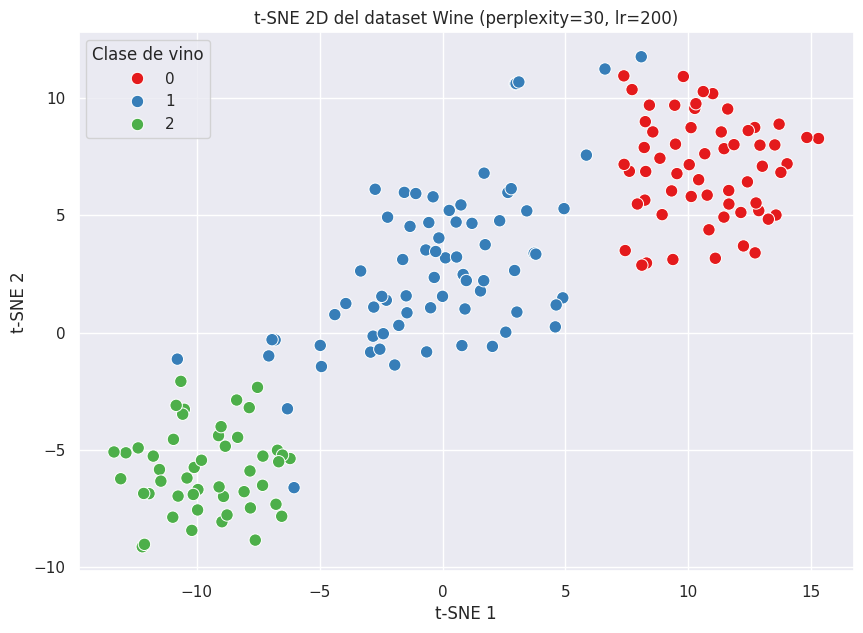

Primeras filas de la proyección t-SNE base:


,TSNE1,TSNE2,wine_class
0,13.567395,5.011970,0
1,8.934541,5.028345,0
2,11.340140,8.552135,0
3,14.019716,7.195169,0
4,7.710810,10.356475,0


In [20]:
# 2. Análisis detallado con t-SNE

# Configuraciones de hiperparámetros a probar
configuraciones_tsne = [
    {"perplexity": 5, "learning_rate": 100},
    {"perplexity": 30, "learning_rate": 200},
    {"perplexity": 50, "learning_rate": 200},
    {"perplexity": 30, "learning_rate": 500}
]

resultados_tsne = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, config in zip(axes, configuraciones_tsne):
    perplexity = config["perplexity"]
    learning_rate = config["learning_rate"]

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
        random_state=42
    )

    X_tsne = tsne.fit_transform(X_wine_scaled)

    df_tsne = pd.DataFrame(
        X_tsne,
        columns=["TSNE1", "TSNE2"]
    )
    df_tsne[target] = y_wine.values

    nombre = f"perplexity={perplexity}, lr={learning_rate}"
    resultados_tsne[nombre] = df_tsne

    sns.scatterplot(
        data=df_tsne,
        x="TSNE1",
        y="TSNE2",
        hue=target,
        palette="Set1",
        s=70,
        ax=ax,
        legend=False
    )

    ax.set_title(nombre)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle("Comparación de t-SNE con distintos hiperparámetros", fontsize=16)
plt.tight_layout()
plt.show()

# Mostrar una configuración base de forma individual
config_base = "perplexity=30, lr=200"
df_tsne_base = resultados_tsne[config_base]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_tsne_base,
    x="TSNE1",
    y="TSNE2",
    hue=target,
    palette="Set1",
    s=80
)
plt.title(f"t-SNE 2D del dataset Wine ({config_base})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Clase de vino")
plt.show()

print("Primeras filas de la proyección t-SNE base:")
display(df_tsne_base.head())

El análisis t-SNE se aplicó para visualizar el dataset Wine en dos dimensiones, probando distintas combinaciones de hiperparámetros como `perplexity` y `learning_rate`. A diferencia de PCA, t-SNE es un método no lineal que busca preservar relaciones locales entre observaciones, por lo que suele ser útil para visualizar grupos o clusters.

En las visualizaciones generadas, se observa que t-SNE logra separar las clases de vino de forma bastante clara. La configuración base utilizada fue `perplexity=30` y `learning_rate=200`. En esta proyección, las observaciones de la clase 0 se agrupan hacia valores positivos de TSNE1 y TSNE2, mientras que la clase 2 se ubica principalmente hacia valores negativos, y la clase 1 queda en una zona intermedia.

Las primeras filas de la proyección t-SNE muestran valores como TSNE1 = **13,57** y TSNE2 = **5,01** para una observación de clase 0, lo que confirma que el método genera nuevas coordenadas artificiales para representar los datos. Estas coordenadas no tienen interpretación directa como las componentes principales de PCA, pero permiten visualizar mejor la separación entre grupos.

En síntesis, t-SNE muestra una separación visual fuerte entre las clases de vino, especialmente útil para exploración gráfica. Sin embargo, sus ejes no representan variables interpretables, y los resultados pueden cambiar dependiendo de los hiperparámetros utilizados.



### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



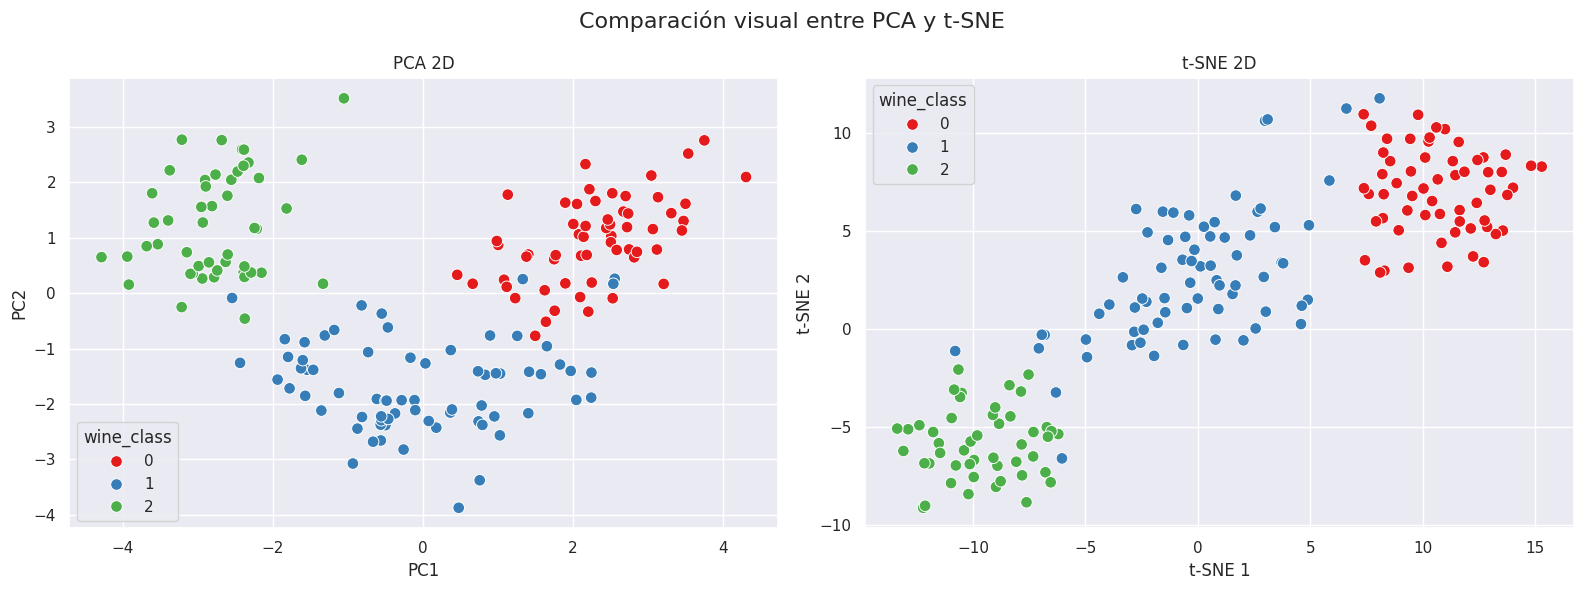

,metodo,tipo,objetivo_principal,interpretabilidad,uso_recomendado,limitacion
0,PCA,Lineal,Maximizar varianza explicada y reducir dimensi...,"Alta, permite analizar loadings y varianza exp...","Reducción previa, compresión, interpretación y...",Puede no capturar relaciones no lineales compl...
1,t-SNE,No lineal,Preservar vecindades locales para visualización,"Baja, los ejes no tienen interpretación directa",Exploración visual de grupos y patrones no lin...,Sensible a hiperparámetros y no ideal para inf...


Centros promedio por clase en PCA:


,PC1,PC2
wine_class,,
0,2.282739,0.967874
1,-0.038986,-1.643483
2,-2.748200,1.241308



Centros promedio por clase en t-SNE:


,TSNE1,TSNE2
wine_class,,
0,10.709783,7.006142
1,-0.184002,2.795163
2,-9.605959,-5.858972


PCA permite interpretar la varianza explicada y los loadings de las variables.
t-SNE suele separar visualmente mejor grupos locales, pero sus ejes no son interpretables.
Ambos métodos son complementarios para explorar datasets de alta dimensión como Wine.


In [27]:
# 3. Comparación entre PCA y t-SNE

# Usar PCA 2D y t-SNE base
df_comparacion_pca = df_pca_2.copy()
df_comparacion_tsne = df_tsne_base.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df_comparacion_pca,
    x="PC1",
    y="PC2",
    hue=target,
    palette="Set1",
    s=70,
    ax=axes[0]
)
axes[0].set_title("PCA 2D")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sns.scatterplot(
    data=df_comparacion_tsne,
    x="TSNE1",
    y="TSNE2",
    hue=target,
    palette="Set1",
    s=70,
    ax=axes[1]
)
axes[1].set_title("t-SNE 2D")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.suptitle("Comparación visual entre PCA y t-SNE", fontsize=16)
plt.tight_layout()
plt.show()

# Tabla comparativa de características metodológicas
comparacion_metodos = pd.DataFrame({
    "metodo": ["PCA", "t-SNE"],
    "tipo": ["Lineal", "No lineal"],
    "objetivo_principal": [
        "Maximizar varianza explicada y reducir dimensiones",
        "Preservar vecindades locales para visualización"
    ],
    "interpretabilidad": [
        "Alta, permite analizar loadings y varianza explicada",
        "Baja, los ejes no tienen interpretación directa"
    ],
    "uso_recomendado": [
        "Reducción previa, compresión, interpretación y modelos posteriores",
        "Exploración visual de grupos y patrones no lineales"
    ],
    "limitacion": [
        "Puede no capturar relaciones no lineales complejas",
        "Sensible a hiperparámetros y no ideal para inferencia global"
    ]
})

display(comparacion_metodos)

# Comparación de separación aproximada usando medias por clase en el espacio reducido
pca_centros = df_comparacion_pca.groupby(target)[["PC1", "PC2"]].mean()
tsne_centros = df_comparacion_tsne.groupby(target)[["TSNE1", "TSNE2"]].mean()

print("Centros promedio por clase en PCA:")
display(pca_centros)

print("\nCentros promedio por clase en t-SNE:")
display(tsne_centros)

# Conclusión programática de apoyo
print("PCA permite interpretar la varianza explicada y los loadings de las variables.")
print("t-SNE suele separar visualmente mejor grupos locales, pero sus ejes no son interpretables.")
print("Ambos métodos son complementarios para explorar datasets de alta dimensión como Wine.")

La comparación entre PCA y t-SNE muestra que ambos métodos son útiles para reducir dimensionalidad, pero cumplen objetivos distintos. PCA es un método lineal que busca maximizar la varianza explicada y permite interpretar la contribución de las variables originales mediante los loadings. En cambio, t-SNE es un método no lineal orientado principalmente a la visualización de vecindades locales.

En la proyección PCA, los centros promedio por clase fueron claramente distintos: la clase 0 se ubicó en torno a **PC1 = 2,28** y **PC2 = 0,97**, la clase 1 cerca de **PC1 = -0,04** y **PC2 = -1,64**, y la clase 2 alrededor de **PC1 = -2,75** y **PC2 = 1,24**. Esto muestra que PCA logra diferenciar las clases, especialmente a través de PC1.

En t-SNE, los centros promedio por clase muestran una separación aún más marcada: la clase 0 se ubicó alrededor de **TSNE1 = 10,71** y **TSNE2 = 7,01**, la clase 1 cerca de **TSNE1 = -0,18** y **TSNE2 = 2,80**, y la clase 2 en torno a **TSNE1 = -9,61** y **TSNE2 = -5,86**. Esto indica que t-SNE produce una separación visual más fuerte entre grupos.

Por lo tanto, PCA es más adecuado cuando se busca interpretar la estructura de los datos, analizar varianza explicada o reducir variables para modelos posteriores. En cambio, t-SNE es más útil cuando el objetivo principal es explorar visualmente la existencia de grupos o patrones no lineales.

En conclusión, ambos métodos son complementarios: PCA entrega interpretabilidad y resumen estadístico, mientras que t-SNE entrega una visualización más clara de la separación entre clases.

El laboratorio permitió aplicar dos familias de técnicas no supervisadas: clustering mediante KMeans y reducción de dimensionalidad mediante PCA y t-SNE.

En la primera parte, KMeans permitió segmentar una base de vehículos en distintos grupos según sus características técnicas, consumo y emisiones. Los resultados muestran que existen perfiles claramente diferenciados: vehículos grandes, de alto consumo y altas emisiones, como los clusters 1 y 6; y vehículos más pequeños y eficientes, como los clusters 3 y 5. Esto demuestra que el clustering puede ser útil para identificar patrones dentro de bases de datos sin etiquetas previas.

La regla del codo mostró que la inercia disminuye a medida que aumenta el número de clusters, aunque no se observa un codo completamente definido. Esto sugiere que la estructura de los datos es compleja y que la elección del número de clusters debe balancear precisión e interpretabilidad.

En la segunda parte, PCA permitió reducir la dimensionalidad del dataset Wine y analizar la importancia de las variables químicas. Las dos primeras componentes explicaron aproximadamente 55,4% de la varianza, mientras que se necesitaron 8 componentes para superar el 90% y 10 componentes para superar el 95%. Además, los loadings mostraron que variables como flavonoides, fenoles, intensidad de color, alcohol y prolina son relevantes para diferenciar los vinos.

Finalmente, t-SNE permitió visualizar con mayor claridad la separación entre clases de vino, aunque con menor interpretabilidad que PCA. En conjunto, el laboratorio muestra que KMeans, PCA y t-SNE son herramientas complementarias: KMeans agrupa observaciones, PCA permite reducir dimensiones con interpretación estadística, y t-SNE facilita la exploración visual de patrones no lineales.